In [1]:
import numpy as np
from scipy.sparse.linalg import spsolve
from scipy.interpolate import griddata
import matplotlib.pyplot as plt


In [2]:
from scipy.sparse import csr_matrix


Start by specifying the domain $\Omega$ by giving the nodes and the elements of an initial (coarse) mesh. 

In [3]:
# Define your nodes and elements here
nodes = np.array([[0.0, 0.0, 1],
                  [1.0, 0.0, 1],
                  [1.0, 1.0, 1],
                  [0.0, 1.0, 1],
                  [0.5798, 0.5986, 0]])  # Interior node (a, b)

# Elements should be defined with 0-based indexing
elements = np.array([[0, 4, 3],  # Triangle 1
                     [4, 2, 3],  # Triangle 2
                     [0, 1, 4],  # Triangle 3
                     [1, 2, 4]])  # Triangle 4


Visualises the nodes and elements of the current mesh.

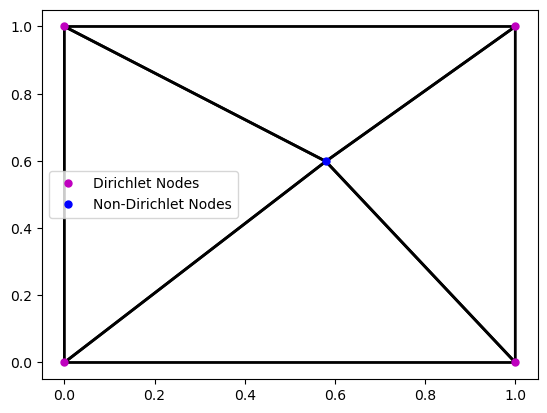

In [4]:
def visualise(nodes, elements):
    plt.figure()
    for element in elements:
        # Extract the vertices for the current element
        vertices = nodes[element, :2]  # Get x, y coordinates
        # Form a closed polygon by appending the first vertex at the end
        polygon = np.vstack([vertices, vertices[0]])
        plt.plot(polygon[:, 0], polygon[:, 1], 'k-', linewidth=2)

    # Find Dirichlet and non-Dirichlet nodes
    ND = nodes[:, 2] == 1
    plt.plot(nodes[ND, 0], nodes[ND, 1], 'm.', markersize=10, label='Dirichlet Nodes')
    plt.plot(nodes[~ND, 0], nodes[~ND, 1], 'b.', markersize=10, label='Non-Dirichlet Nodes')
    plt.legend()
    plt.show()

# Example usage with the same nodes and elements:
visualise(nodes, elements)

Uniformly refine the mesh as many times as specified in `nref`.

In [30]:
def refine(nodes, elements):
    nnodes, m = nodes.shape
    nelts, m = elements.shape

    newnodes = nodes.copy()
    newelements = np.zeros((4 * nelts, 3), dtype=int)
    inode = nnodes
    edgetable = {}

    # Function to find or create a midpoint node
    def find_or_create_midpoint(n1, n2):
        edge_key = tuple(sorted((n1, n2)))
        if edge_key in edgetable:
            return edgetable[edge_key]
        else:
            newnode = (nodes[n1, :2] + nodes[n2, :2]) / 2
            nonlocal inode
            edgetable[edge_key] = inode
            newnodes_list.append(newnode)
            inode += 1
            return inode - 1

    newnodes_list = []

    for ie in range(nelts):
        newloc = [0] * 3
        for edge in range(3):
            n1 = elements[ie, edge]
            n2 = elements[ie, (edge + 1) % 3]
            newloc[edge] = find_or_create_midpoint(n1, n2)
        newelements[4 * ie, :] = [elements[ie, 0], newloc[0], newloc[2]]
        newelements[4 * ie + 1, :] = [newloc[0], elements[ie, 1], newloc[1]]
        newelements[4 * ie + 2, :] = [newloc[1], elements[ie, 2], newloc[2]]
        newelements[4 * ie + 3, :] = newloc

    # Add boundary conditions for new nodes
    for newnode_coords in newnodes_list:
        boundary_condition = 0
        # Check if the new node is on the boundary (x=0, x=1, y=0, y=1)
        if (np.isclose(newnode_coords[0], 0) or np.isclose(newnode_coords[0], 1) or
                np.isclose(newnode_coords[1], 0) or np.isclose(newnode_coords[1], 1)):
            boundary_condition = 1
        
        # Check if the new node is the special interior node (a, b)
        if np.allclose(newnode_coords, [0.5798, 0.5986], atol=1e-3):
            boundary_condition = 0
        
        newnodes = np.vstack((newnodes, np.append(newnode_coords, boundary_condition)))

    return newnodes, newelements


In [31]:
def visited(edges, node1, node2):
    nedges, m = edges.shape

    for i in range(1, nedges + 1):
        if ((edges[i - 1, 0] == node1 and edges[i - 1, 1] == node2) or
            (edges[i - 1, 0] == node2 and edges[i - 1, 1] == node1)):
            return i

    return 0

In [32]:
# Uniform refinement of the mesh
nref = 1
for i in range(nref):
    nodes, elements = refine(nodes, elements)

nnodes, m = nodes.shape

Visualise the refined mesh (if not too fine).

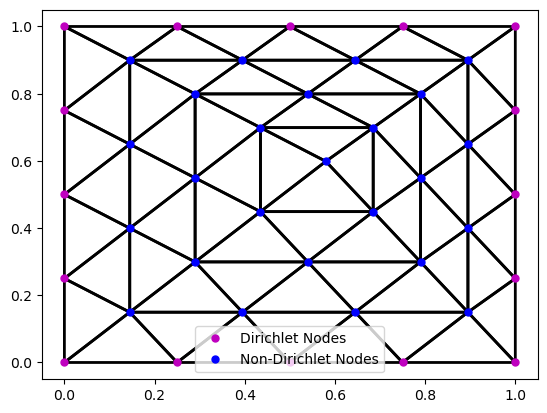

In [33]:
if nnodes < 1000:
    visualise(nodes, elements)

Compute the element stiffness matrices.

In [34]:
import numpy as np
from mu_area import mu_area

def elt_stiffness(elements, nodes):
    nelts, m = elements.shape  # Finds how many elements there are

    elt_matrices = [None] * nelts

    for ie in range(nelts):
        elt_matrices[ie] = np.zeros((3, 3))

        X = nodes[elements[ie].astype(int), :2] # Coordinates of 3 nodes of element ie

        area = mu_area(X)  # Area of element ie using the determinant formula from lectures

        E = np.array([X[1, :] - X[2, :], X[2, :] - X[0, :], X[0, :] - X[1, :]])

        # Now we implement the formula given in lectures for the
        # element stiffness matrices corresponding to the Laplacian.

        Atau = np.array([[np.dot(E[0, :], E[0, :]), np.dot(E[0, :], E[1, :]), np.dot(E[0, :], E[2, :])],
                         [np.dot(E[1, :], E[0, :]), np.dot(E[1, :], E[1, :]), np.dot(E[1, :], E[2, :])],
                         [np.dot(E[2, :], E[0, :]), np.dot(E[2, :], E[1, :]), np.dot(E[2, :], E[2, :])]])

        elt_matrices[ie] = Atau / (4 * area)

    return elt_matrices


In [35]:
import numpy as np

def mu_area(X):
    # Takes three nodes of a triangle, listed as the rows
    # of a matrix X and finds the area of this triangle
    a = np.abs(np.linalg.det(np.column_stack((np.ones(3), X))) / 2)
    return a


In [36]:
elt_matrices = elt_stiffness(elements, nodes)

Assemble the global extended stiffness matrix.

In [37]:
def global_stiffness(elt_matrices, elements, nodes):
    nelts, m = elements.shape
    nnodes, _ = nodes.shape

    # Create an empty sparse matrix with nnodes columns and rows
    Ahat = csr_matrix((nnodes, nnodes), dtype=float)

    for ie in range(nelts):
        iglob = elements[ie, :]
        # Loop to add the element stiffness matrix to the global matrix
        for i, row in enumerate(iglob):
            for j, col in enumerate(iglob):
                Ahat[row, col] += elt_matrices[ie][i, j]

    return Ahat


In [38]:
Ahat = global_stiffness(elt_matrices, elements, nodes)

Select appropriate blocks of $\hat{A}$ to get the stiffness matrix $A$.

In [39]:
N0 = np.where(nodes[:, 2] != 1)[0]
A = Ahat[N0][:, N0]
print(A[:5, :5].todense()) 

[[4.13319848 0.         0.         0.         0.        ]
 [0.         3.75227899 0.         0.         0.        ]
 [0.         0.         4.17584224 0.         0.        ]
 [0.         0.         0.         4.51392582 0.        ]
 [0.         0.         0.         0.         4.09036257]]


Define the source term for Poisson's equation.

In [40]:
def source_term(x1, x2):
    e = np.exp(1)  # Euler's number
    return -e**x1 * ((x1 + 3) * (x2 - 1) * x2 + 2 * (x1 - 1))
f_obj = source_term

Compute the load vector.

In [41]:
import numpy as np
from mu_area import mu_area

def rhs(func, N0, elements, nodes):
    nelts, m = elements.shape  # Finds how many elements there are
    nnodes, m = nodes.shape     # Finds how many nodes there are

    fhat = np.zeros(nnodes)      # Initialize with a vector of zeros

    for ie in range(1, nelts + 1):
        X = nodes[elements[ie - 1].astype(int)-1, :2]  # Coordinates of 3 nodes of element ie

        area = mu_area(X)  # Area of element ie

        for p in range(1, 4):
            i = elements[ie - 1, p - 1].astype(int)
            fhat[i - 1] += func(X[p - 1, 0], X[p - 1, 1]) * area / 3

    return fhat[N0] 


In [42]:
import numpy as np

def mu_area(X):
    # Takes three nodes of a triangle, listed as the rows
    # of a matrix X and finds the area of this triangle
    a = np.abs(np.linalg.det(np.column_stack((np.ones(3), X))) / 2)
    return a


In [43]:
f = rhs(f_obj, N0, elements, nodes)

Solve the linear system to get the FEM solution coefficients.

In [44]:
U = spsolve(A, f)

Compute the extended vector $\hat{U}$.

In [45]:
Uhat = np.zeros(nnodes)
Uhat[N0] = U

Plot the FEM solution.

Text(0.5, 0.92, 'Numerical solution')

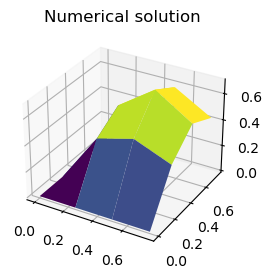

In [46]:
h_unif = 1 / (2 ** (nref + 1)) # to have a regular grid size comparable to the one used for FEM computations
XI, YI = np.meshgrid(np.arange(min(nodes[:, 0]), max(nodes[:, 0]), h_unif),
                     np.arange(min(nodes[:, 1]), max(nodes[:, 1]), h_unif))
ZI = griddata(nodes[:,:2], Uhat, (XI, YI), method='linear')

fig = plt.figure()
ax = fig.add_subplot(121, projection='3d')
ax.plot_surface(XI, YI, ZI, cmap='viridis')
ax.set_title('Numerical solution')

In [47]:
print(U)

[0.7460847  0.45813446 0.37453767 0.30938461 0.35773958 0.22545417
 0.29726674 0.67421988 0.64848769 0.5867444  0.13220599 0.35379852
 0.59072785 0.53053177 0.09813753 0.24210713 0.28343463 0.31649683
 0.19931265 0.35608994 0.62569867 0.53400332 0.22659399 0.28956801
 0.4582189 ]


Evaluate the exact solution at the nodes.

In [48]:
def exact_solution(x1, x2):
    return x1 * (1 - x1) * np.exp(x1) * x2 * (1 - x2)
# Evaluate the exact solution at each node of the initial mesh
exact_at_nodes = np.array([exact_solution(node[0], node[1]) for node in nodes])

# Extract the (a, b) coordinates from the nodes array
# It is the interior node, which should be the last in our nodes list
a, b = nodes[-1, :2]

# Compute the exact solution at (a, b)
exact_at_ab = exact_solution(a, b)

# Show the exact solution at nodes and at (a, b)
exact_at_nodes, exact_at_ab

(array([0.        , 0.        , 0.        , 0.        , 0.10453273,
        0.05769106, 0.04412928, 0.        , 0.05865494, 0.        ,
        0.        , 0.07668073, 0.        , 0.01823204, 0.03437519,
        0.        , 0.0939172 , 0.07988052, 0.0681031 , 0.01293456,
        0.        , 0.03260936, 0.09007911, 0.06837516, 0.02077101,
        0.        , 0.03940077, 0.        , 0.03202204, 0.        ,
        0.04513697, 0.        , 0.02927798, 0.05553774, 0.10590789,
        0.08938816, 0.        , 0.05520152, 0.        , 0.05236586,
        0.09052   ]),
 0.09051999776911267)

In [49]:
a, b = nodes[-1, :2]

# Print the coordinates (a, b)
print("Coordinates of (a, b):", a, b)

Coordinates of (a, b): 0.7899 0.5493


Plot the exact solution.

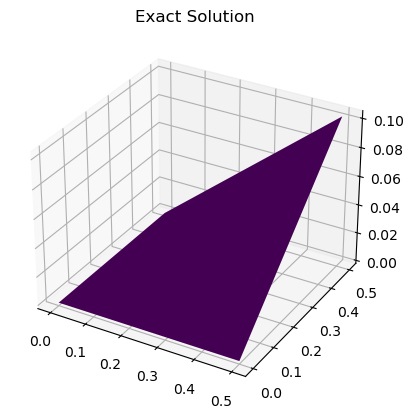

In [50]:
def source_term(x1, x2):
    e = np.exp(1)  # Euler's number
    return -e**x1 * ((x1 + 3) * (x2 - 1) * x2 + 2 * (x1 - 1))

# Define the exact solution given by the user
def exact_solution(x1, x2):
    return x1 * (1 - x1) * np.exp(x1) * x2 * (1 - x2)

# Now, let's plot the exact solution on a meshgrid to visualize it
h_unif = 1 / 2  # assuming a coarse grid for visualization
XI, YI = np.meshgrid(np.arange(0, 1, h_unif), np.arange(0, 1, h_unif))
ZI_exact = exact_solution(XI, YI)

# Plotting the exact solution
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
ax.plot_surface(XI, YI, ZI_exact, cmap='viridis')
ax.set_title('Exact Solution')

plt.show()

Calculate error at nodes and plot it.

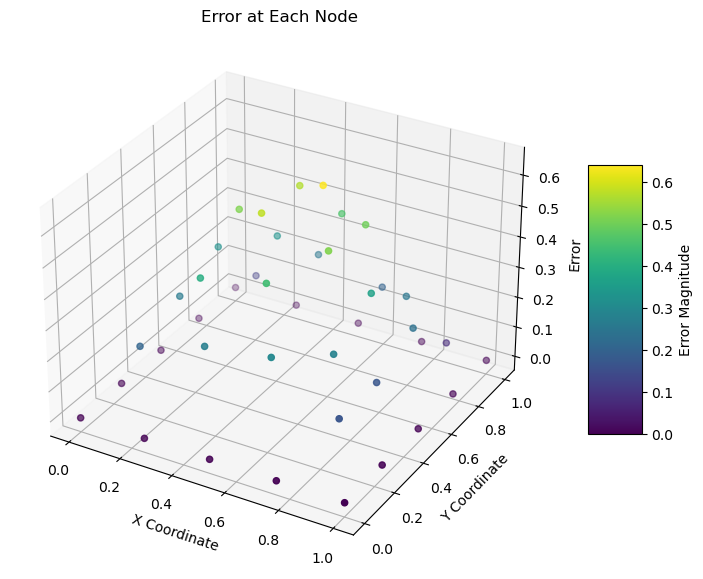

[0.         0.         0.         0.         0.64155197 0.4004434
 0.33040838 0.         0.25072967 0.         0.         0.28105885
 0.         0.20722213 0.26289155 0.         0.58030268 0.56860716
 0.5186413  0.11927143 0.         0.32118916 0.50064874 0.46215661
 0.07736652 0.         0.20270636 0.         0.25141259 0.
 0.27135986 0.         0.17003467 0.3005522  0.51979077 0.44461516
 0.         0.17139248 0.         0.23720215 0.3676989 ]


In [51]:
# Calculate the exact solution at each node of the refined mesh
exact_at_nodes_refined = np.array([exact_solution(node[0], node[1]) for node in nodes])

# Calculate the error at each node using Uhat and exact_at_nodes_refined
error_at_nodes = np.abs(exact_at_nodes_refined - Uhat)

# Plot the error at each node
fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')

# Extract X, Y coordinates and the error for coloring
X, Y = nodes[:, 0], nodes[:, 1]
scatter = ax.scatter(X, Y, error_at_nodes, c=error_at_nodes, cmap='viridis', depthshade=True)

# Adding labels and title
ax.set_xlabel('X Coordinate')
ax.set_ylabel('Y Coordinate')
ax.set_zlabel('Error')
ax.set_title('Error at Each Node')

# Adding a color bar to interpret the error magnitudes
color_bar = fig.colorbar(scatter, ax=ax, shrink=0.5, aspect=5)
color_bar.set_label('Error Magnitude')

plt.show()
print(error_at_nodes)

Calculate the measure for the error (energy norm).

In [52]:
def energy_norm_element_wise(elt_matrices, elements, nodes, Uhat):
    energy_norm = 0
    for ie, elt in enumerate(elements):
        # Get the indices of the nodes for this element
        node_indices = elements[ie]
        # Get the values of Uhat for these nodes
        u_h_values = Uhat[node_indices]
        # Get the exact values for these nodes
        u_values = np.array([exact_solution(nodes[idx, 0], nodes[idx, 1]) for idx in node_indices])
        # Calculate the error for these nodes
        e_values = u_values - u_h_values
        # Get the area of the element
        area = mu_area(nodes[node_indices, :2])
        # Approximate the integral of the square of the gradient over the element using the stiffness matrix
        energy_norm += (e_values @ elt_matrices[ie] @ e_values) * area
    return np.sqrt(energy_norm)

# Calculate the energy norm for the error
energy_norm_error = energy_norm_element_wise(elt_matrices, elements, nodes, Uhat)
energy_norm_error

0.185286157025082

In [53]:
# Interpolate the solution values at the specified points (a, b) and (0.92, 0.2)
uh_at_ab = griddata(nodes[:,:2], Uhat, [(0.5798, 0.5986)], method='linear')[0]
uh_at_point = griddata(nodes[:,:2], Uhat, [(0.92, 0.2)], method='linear')[0]

# Compute the exact solution at the specified points
exact_at_ab = exact_solution(0.5798, 0.5986)
exact_at_point = exact_solution(0.92, 0.2)

# Compute the absolute errors
error_at_ab = abs(exact_at_ab - uh_at_ab)
error_at_point = abs(exact_at_point - uh_at_point)

# Print the absolute errors
print("Absolute error at (a, b):", error_at_ab)
print("Absolute error at (0.92, 0.2):", error_at_point)


Absolute error at (a, b): 0.6415519682813277
Absolute error at (0.92, 0.2): 0.11791465144172564


In [54]:
# Define function to compute absolute error at specified points
def compute_absolute_error(nodes, Uhat, exact_solution, points):
    errors = []
    for point in points:
        x, y = point
        uh_at_point = griddata(nodes[:,:2], Uhat, [(x, y)], method='linear')[0]
        exact_at_point = exact_solution(x, y)
        error_at_point = abs(exact_at_point - uh_at_point)
        errors.append(error_at_point)
    return errors

# Define points to evaluate absolute error
point_a_b = [0.5798, 0.5986]
point_092_02 = [0.92, 0.2]
points = [point_a_b, point_092_02]

# Define a function to run the simulation for a given number of refinements
def run_simulation(num_refinements):
    # Initial mesh
    nodes = np.array([[0.0, 0.0, 1],
                      [1.0, 0.0, 1],
                      [1.0, 1.0, 1],
                      [0.0, 1.0, 1],
                      [0.5798, 0.5986, 0]])  # Interior node (a, b)

    elements = np.array([[0, 4, 3],  # Triangle 1
                         [4, 2, 3],  # Triangle 2
                         [0, 1, 4],  # Triangle 3
                         [1, 2, 4]])  # Triangle 4
    
    # Uniform refinement of the mesh
    for i in range(num_refinements):
        nodes, elements = refine(nodes, elements)
    
    # Compute finite element solution
    elt_matrices = elt_stiffness(elements, nodes)
    Ahat = global_stiffness(elt_matrices, elements, nodes)
    N0 = np.where(nodes[:, 2] != 1)[0]
    A = Ahat[N0][:, N0]
    f = rhs(source_term, N0, elements, nodes)
    U = spsolve(A, f)
    Uhat = np.zeros(len(nodes))
    Uhat[N0] = U
    
    # Compute absolute errors
    absolute_errors = compute_absolute_error(nodes, Uhat, exact_solution, points)
    
    return absolute_errors

# Define the number of refinements for each mesh size
num_refinements_list = [2, 3, 4, 5, 6]

# Run the simulation for each mesh size and collect the results
results = []
for num_refinements in num_refinements_list:
    absolute_errors = run_simulation(num_refinements)
    results.append(absolute_errors)

# Tabulate the results
print("Mesh Size\t| Error at (a, b)\t| Error at (0.92, 0.2)")
print("-------------------------------------------------------")
for i, num_refinements in enumerate(num_refinements_list):
    error_at_a_b = results[i][0]
    error_at_092_02 = results[i][1]
    print(f"{num_refinements}\t\t| {error_at_a_b:.6f}\t\t| {error_at_092_02:.6f}")


Mesh Size	| Error at (a, b)	| Error at (0.92, 0.2)
-------------------------------------------------------
2		| 0.641552		| 0.117915
3		| 1.083904		| 0.191182
4		| 1.413971		| 0.266903
5		| 1.744593		| 0.328117
6		| 2.032598		| 0.388144


In [56]:
import numpy as np

# Function to calculate convergence rate
def convergence_rate(errors, mesh_sizes):
    rates = []
    for i in range(1, len(errors)):
        rate = np.log(errors[i] / errors[i-1]) / np.log(mesh_sizes[i] / mesh_sizes[i-1])
        rates.append(rate)
    return rates

# List to store errors and mesh sizes
errors_at_points = {point: [] for point in points}
mesh_sizes = []

# Run the simulation for each mesh size and collect the results
for num_refinements in num_refinements_list:
    Uhat, nodes, elements = run_simulation(num_refinements, initial_nodes, initial_elements)
    interpolated_values = griddata(nodes[:, :2], Uhat, points, method='linear')
    exact_values = [exact_solution(*pt) for pt in points]
    errors = np.abs(exact_values - interpolated_values)
    
    # Store errors and mesh size
    for i, pt in enumerate(points):
        errors_at_points[pt].append(errors[i])
    mesh_sizes.append(1 / (2 ** num_refinements))  # Assuming uniform refinement

# Calculate convergence rates for each point
rates_at_points = {}
for point, errors in errors_at_points.items():
    rates_at_points[point] = convergence_rate(errors, mesh_sizes)

# Print convergence rates
print("Convergence rates:")
for point, rates in rates_at_points.items():
    print(f"At point {point}:")
    for i, rate in enumerate(rates, start=2):
        print(f"Refinement {i-1}-{i}: {rate:.4f}")
    print("----------------------------")


TypeError: unhashable type: 'list'

In [55]:
# Define a function to estimate the convergence rate using Richardson extrapolation
def estimate_convergence_rate(errors, h_values):
    num_errors = len(errors)
    p_values = []
    for i in range(num_errors - 1):
        p = np.log(errors[i] / errors[i+1]) / np.log(h_values[i] / h_values[i+1])
        p_values.append(p)
    return p_values

# Define mesh sizes and corresponding errors for each quantity
mesh_sizes = [1/2**i for i in range(2, 7)]  # Example sequence of mesh sizes
errors_a_b = [0.641552, 1.083904, 1.413971, 1.744593, 2.032598]  # Errors at (a, b)
errors_092_02 = [0.117915, 0.191182, 0.266903, 0.328117, 0.388144]  # Errors at (0.92, 0.2)

# Estimate convergence rates for each quantity
p_values_a_b = estimate_convergence_rate(errors_a_b, mesh_sizes)
p_values_092_02 = estimate_convergence_rate(errors_092_02, mesh_sizes)

# Print the convergence rates
print("Convergence rates for error at (a, b):", p_values_a_b)
print("Convergence rates for error at (0.92, 0.2):", p_values_092_02)


Convergence rates for error at (a, b): [-0.7565988741128369, -0.38351554664832027, -0.30313797480621807, -0.22043440616510201]
Convergence rates for error at (0.92, 0.2): [-0.6971994427244195, -0.48136882316450863, -0.29789482143939205, -0.24238164333105885]


In [31]:
def compute_H1_error(U_ex, U, A):
    difference = U_ex - U
    error_squared = np.dot(difference, A.dot(difference))  # (U_ex - U)^T * A * (U_ex - U)
    return np.sqrt(error_squared)
def compute_exact_solution_coeffs(nodes):
    return np.array([exact_solution(x, y) for x, y in nodes[:,:2]])

In [32]:
def run_simulation_for_H1_error(num_refinements):
    # Initial mesh setup
    nodes = np.array([[0.0, 0.0, 1],
                      [1.0, 0.0, 1],
                      [1.0, 1.0, 1],
                      [0.0, 1.0, 1],
                      [0.5798, 0.5986, 0]])  # Interior node (a, b)
    elements = np.array([[0, 4, 3],  # Triangle 1
                         [4, 2, 3],  # Triangle 2
                         [0, 1, 4],  # Triangle 3
                         [1, 2, 4]])  # Triangle 4
    
    # Refine the mesh based on the number of refinements
    for i in range(num_refinements):
        nodes, elements = refine(nodes, elements)
    
    # Compute finite element solution
    elt_matrices = elt_stiffness(elements, nodes)
    Ahat = global_stiffness(elt_matrices, elements, nodes)
    N0 = np.where(nodes[:, 2] != 1)[0]
    A = Ahat[N0][:, N0]
    f = rhs(source_term, N0, elements, nodes)
    U = spsolve(A, f)
    
    # Compute exact solution coefficients at mesh nodes
    U_ex = compute_exact_solution_coeffs(nodes[N0])  
    
    # Compute H1 error
    H1_error = compute_H1_error(U_ex, U, A)
    
    return H1_error

# Running the simulation across refinement levels
results_H1 = []
for num_refinements in [2, 3, 4, 5, 6]:
    H1_error = run_simulation_for_H1_error(num_refinements)
    results_H1.append((num_refinements, H1_error))

# Output results
for level, error in results_H1:
    print(f"Mesh refinement level {level}: H1 Error = {error:.6f}")


Mesh refinement level 2: H1 Error = 1.482855
Mesh refinement level 3: H1 Error = 2.749003
Mesh refinement level 4: H1 Error = 3.552311
Mesh refinement level 5: H1 Error = 4.384176
Mesh refinement level 6: H1 Error = 5.098592


In [63]:
def diagnose_elements_and_solver(elements, nodes, A, U):
    for e in elements:
        vertices = nodes[e[:3], :2]
        area = mu_area(vertices)
        aspect_ratio = calculate_aspect_ratio(vertices)  # Define this function as needed
        if area < threshold_area or aspect_ratio > max_aspect_ratio:  # Define these thresholds
            print(f"Problematic element: {e}, Area: {area}, Aspect Ratio: {aspect_ratio}")

    # Check matrix condition number
    from numpy.linalg import cond
    cond_number = cond(A.todense())  # Ensure A is in a dense format for this operation
    print(f"Condition Number of the Stiffness Matrix: {cond_number}")

    # Solver performance check
    residuals = A @ U - f  # Assuming f is your load vector
    residual_norm = np.linalg.norm(residuals)
    print(f"Norm of Residuals: {residual_norm}")

# Use these diagnostic tools after your FEM solve process to get insights
